In [9]:
import os
import cv2
import numpy as np
import mediapipe as mp

Extract landmarks in a matrix with dimensions: (Frames, Landmarks, 3DCoordinates) = (T, 21, 3)

In [ ]:
class RPSFeatureExtractor:
    def __init__(self, sequence_length=15):
        self.sequence_length = sequence_length
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.mp_drawing = mp.solutions.drawing_utils
        
    def extract_landmarks_from_video(self, video_path):
        """Extract hand landmarks from a video file"""
        cap = cv2.VideoCapture(video_path)
        landmarks_sequence = []
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
                
            # Convert BGR to RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Process frame
            results = self.hands.process(rgb_frame)
            
            if results.multi_hand_landmarks:
                # Get first hand landmarks
                hand_landmarks = results.multi_hand_landmarks[0]

                # Extract x, y, z coordinates
                landmarks = []
                for lm in hand_landmarks.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])
                
                landmarks_sequence.append(landmarks)
            else:
                # If no hand detected, use previous frame or zeros
                if landmarks_sequence:
                    landmarks_sequence.append(landmarks_sequence[-1])
                else:
                    landmarks_sequence.append([0.0] * 63)  # 21 landmarks * 3 coordinates
        
        cap.release()
        return np.array(landmarks_sequence)
    
    def normalize_landmarks(self, landmarks):
        """Normalize landmarks relative to wrist position"""
        if len(landmarks) == 0:
            return landmarks
            
        normalized = landmarks.copy()
        
        for i in range(len(landmarks)):
            if np.sum(landmarks[i]) == 0:  # Skip zero frames
                continue
                
            # Reshape to get individual landmarks
            frame_landmarks = landmarks[i].reshape(21, 3)
            
            # Get wrist position (landmark 0)
            wrist = frame_landmarks[0]
            
            # Subtract wrist position from all landmarks
            frame_landmarks = frame_landmarks - wrist
            
            # Calculate hand size (distance from wrist to middle finger tip)
            hand_size = np.linalg.norm(frame_landmarks[12])  # Middle finger tip
            
            # Normalize by hand size (avoid division by zero)
            if hand_size > 0:
                frame_landmarks = frame_landmarks / hand_size
            
            normalized[i] = frame_landmarks.flatten()
        
        return normalized
    
    def create_sequences(self, landmarks, label):
        """Create fixed-length sequences from landmark data"""
        sequences = []
        labels = []
        
        if len(landmarks) < self.sequence_length:
            # If video is too short, pad with last frame
            padding = [landmarks[-1]] * (self.sequence_length - len(landmarks))
            landmarks = np.vstack([landmarks, padding])
        
        # Create overlapping sequences
        for i in range(len(landmarks) - self.sequence_length + 1):
            sequence = landmarks[i:i + self.sequence_length]
            sequences.append(sequence)
            labels.append(label)
        
        return np.array(sequences), np.array(labels)
    
    def extract_landmarks(self, video_dir, destination_dir):
        """Process all videos in a directory structure"""
        
        all_sequences = []
        all_labels = []

        # Expected directory structure: video_dir/gesture_name/video_files
        gesture_dirs = [d for d in os.listdir(video_dir) if os.path.isdir(os.path.join(video_dir, d))]
        
        for gesture_name in gesture_dirs:

            gesture_path = os.path.join(video_dir, gesture_name)
            video_files = [f for f in os.listdir(gesture_path) if f.endswith(('.mp4', '.avi', '.mov'))]
            
            print(f"Processing {len(video_files)} videos for gesture: {gesture_name}")
            
            for video_file in video_files:

                video_path = os.path.join(gesture_path, video_file)
                video_file_name = video_file.split('.')[0]

                # Extract landmarks
                landmarks = self.extract_landmarks_from_video(video_path)

                if len(landmarks) > 0:
                    # Normalize landmarks
                    normalized_landmarks = self.normalize_landmarks(landmarks)
                    
                    # Create sequences
                    sequences, labels = self.create_sequences(normalized_landmarks, gesture_name)
                    
                    all_sequences.extend(sequences)
                    all_labels.extend(labels)

                # Save to .npz files
                normalized_landmarks_3d = normalized_landmarks.reshape(-1, 21, 3)
                print(f"Saving landmarks for {video_file_name} with shape {normalized_landmarks_3d.shape}")
                
                np.savez(os.path.join(destination_dir, f"{video_file_name}_landmarks.npz"),
                landmarks=  normalized_landmarks_3d,
                label=gesture_name)

        all_sequences = np.array(all_sequences)
        all_labels = np.array(all_labels)
                
        return np.array(all_sequences), np.array(all_labels)


In [44]:
feature_extractor = RPSFeatureExtractor(sequence_length=15)
sequences, labels = feature_extractor.extract_landmarks('./data', './features')

I0000 00:00:1757337551.648742  225562 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M3 Pro
W0000 00:00:1757337551.653161  305985 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1757337551.658573  305985 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing 45 videos for gesture: paper
Extracted (57, 63) frames from paper_9
Saving landmarks for paper_9 with shape (57, 21, 3)
Extracted (57, 63) frames from paper_8
Saving landmarks for paper_8 with shape (57, 21, 3)
Extracted (57, 63) frames from paper_14
Saving landmarks for paper_14 with shape (57, 21, 3)
Extracted (58, 63) frames from paper_28
Saving landmarks for paper_28 with shape (58, 21, 3)
Extracted (58, 63) frames from paper_29
Saving landmarks for paper_29 with shape (58, 21, 3)
Extracted (58, 63) frames from paper_15
Saving landmarks for paper_15 with shape (58, 21, 3)
Extracted (61, 63) frames from paper_17
Saving landmarks for paper_17 with shape (61, 21, 3)
Extracted (61, 63) frames from paper_16
Saving landmarks for paper_16 with shape (61, 21, 3)
Extracted (57, 63) frames from paper_12
Saving landmarks for paper_12 with shape (57, 21, 3)
Extracted (57, 63) frames from paper_13
Saving landmarks for paper_13 with shape (57, 21, 3)
Extracted (60, 63) frames from pap

In [45]:
data = np.load("/Users/christina/code/RockPaperScissors/my_rps_dataset/features/paper_0_landmarks.npz")

In [48]:
data['landmarks'].shape

(55, 21, 3)

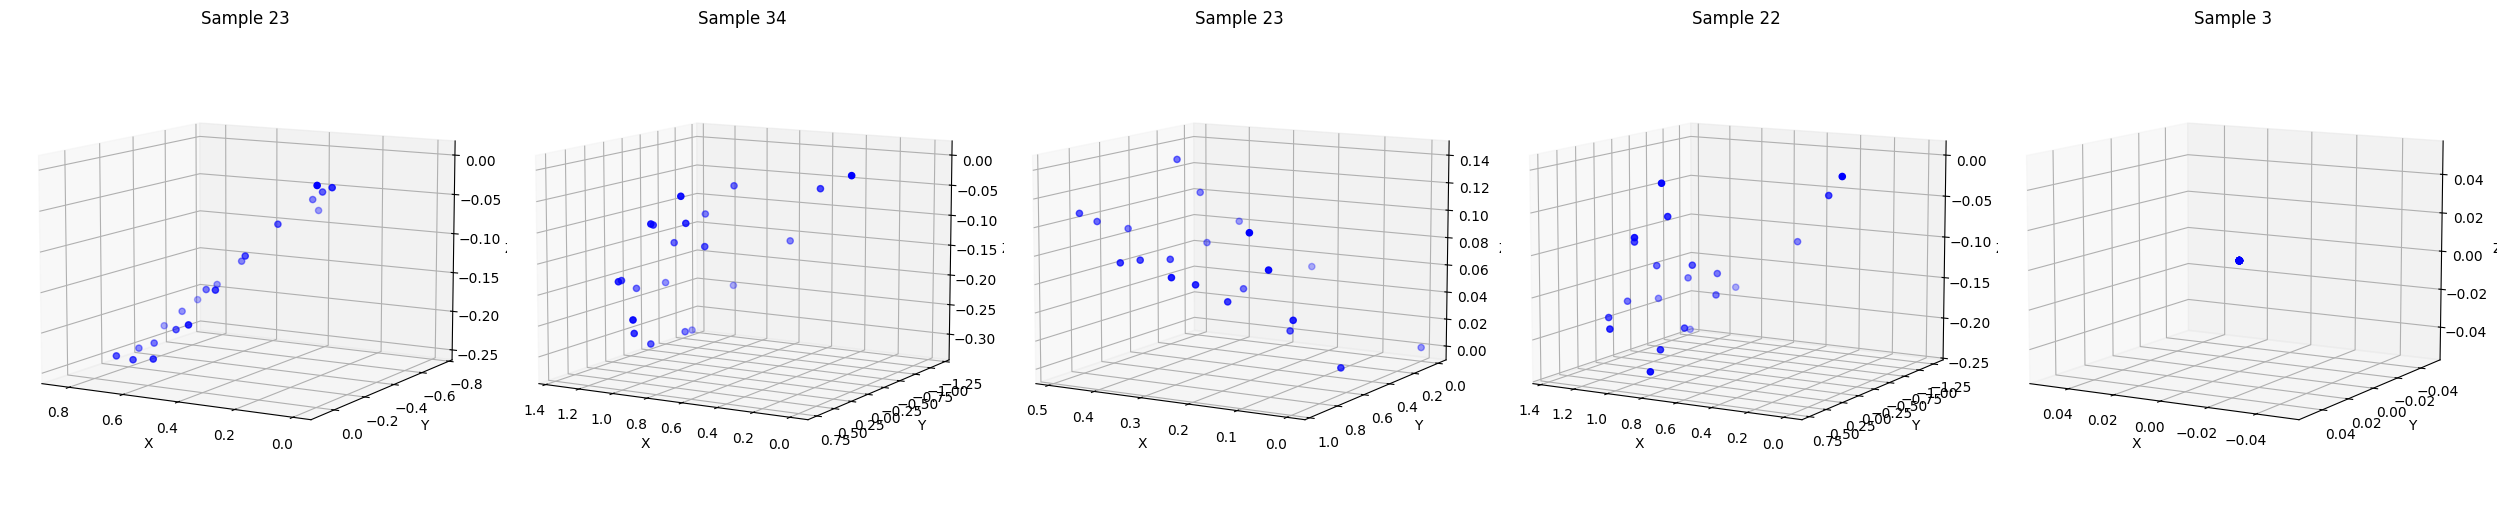

In [61]:
import random

import matplotlib.pyplot as plt

def plot_random_landmark_sample(sequences, num_samples=3):
    """
    Visualize random samples of hand landmarks from the sequences array.
    Each sample shows the landmarks for the first frame in the sequence.
    """
    fig = plt.figure(figsize=(5 * num_samples, 5))
    for i in range(num_samples):
        s = random.randint(0, 45 - 1)
        data = np.load(f"/Users/christina/code/RockPaperScissors/my_rps_dataset/features/paper_{s}_landmarks.npz")
        #sample = sequences[idx][0]  # first frame of the sequence
        #landmarks = sample.reshape(21, 3)
        idx = random.randint(0, 50 - 1)
        landmarks = data['landmarks'][idx]
        ax = fig.add_subplot(1, num_samples, i + 1, projection='3d')
        ax.scatter(landmarks[:, 0], landmarks[:, 1], landmarks[:, 2], c='b')
        ax.set_title(f'Sample {idx}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.view_init(elev=10, azim=120)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_random_landmark_sample(sequences, num_samples=5)